<a href="https://colab.research.google.com/github/AryanRajendraDalvi/-Sentinel-2-Land-Cover-Classification/blob/main/sentinel2_land_cover_mlflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentinel-2 Land Cover Classification
**EuroSAT Benchmark | CNN Segmentation | Band Ablation Study**

This notebook covers the full pipeline:
1. Download & inspect EuroSAT Sentinel-2 GeoTIFF data
2. Preprocess: band stacking, cloud masking, patch extraction, normalization
3. Build a lightweight CNN classifier
4. Train with MLflow experiment tracking
5. Ablation study: RGB-only vs. all-13-band input
6. Evaluation: per-class accuracy, confusion matrix, visual predictions

## 0. Install Dependencies

In [1]:
# Run once
!pip install rasterio GDAL geopandas torch torchvision mlflow numpy matplotlib scikit-learn tqdm Pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

## 1. Imports & Config

In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm

import rasterio
from rasterio.enums import Resampling
from rasterio.plot import show as rio_show

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import csv
import mlflow
from datetime import datetime



# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [3]:
# ── Global Config ─────────────────────────────────────────────────────────────
CFG = {
    'data_root'   : './EuroSAT_MS',       # path to EuroSAT multispectral GeoTIFFs
    'patch_size'  : 64,                   # spatial crop size (EuroSAT tiles are 64x64)
    'batch_size'  : 64,
    'num_workers' : 4,
    'epochs'      : 30,
    'lr'          : 1e-3,
    'weight_decay': 1e-4,
    'val_split'   : 0.15,
    'test_split'  : 0.10,
    'num_classes' : 10,
    # Band indices (0-indexed, all 13 Sentinel-2 bands)
    # B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B10,B11,B12
    'all_bands'   : list(range(13)),
    # RGB = B4(red), B3(green), B2(blue) → indices 3,2,1
    'rgb_bands'   : [3, 2, 1],
    # Cloud mask: B10 (Cirrus) index = 10
    'cirrus_band' : 10,
    'cirrus_thresh': 0.004,               # reflectance threshold for cirrus masking
}

CLASSES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
print('Classes:', CLASSES)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2. Download EuroSAT Dataset
EuroSAT is a public benchmark of 27,000 labelled Sentinel-2 patches across 10 land-use classes.  
We use the **multispectral** version (13-band GeoTIFF), not the RGB-only JPEG version.

In [4]:
import zipfile
import ssl
import requests

# ── Two mirror options (try both if one fails) ────────────────────────────────
MIRRORS = [
    'https://madm.dfki.de/files/sentinel/EuroSATallBands.zip',
    'https://zenodo.org/record/7711810/files/EuroSATallBands.zip',  # Zenodo backup
]
ZIP_PATH = './EuroSATallBands.zip'

def download_with_progress(url, dest, chunk_mb=8):
    """Stream-download with a simple progress bar. SSL verification disabled
    to work around corporate/Jupyter proxy cert chains."""
    print(f'  Source : {url}')
    resp = requests.get(url, stream=True, verify=False, timeout=120)
    resp.raise_for_status()
    total  = int(resp.headers.get('content-length', 0))
    chunk  = chunk_mb * 1024 * 1024
    done   = 0
    with open(dest, 'wb') as f:
        for data in resp.iter_content(chunk_size=chunk):
            f.write(data)
            done += len(data)
            if total:
                pct = done / total * 100
                bar = '#' * int(pct // 4) + '-' * (25 - int(pct // 4))
                print(f'\r  [{bar}] {pct:5.1f}%  ({done/1e6:.0f}/{total/1e6:.0f} MB)', end='')
    print('\n  Download complete.')

if not Path(CFG['data_root']).exists():
    import urllib3
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    for mirror in MIRRORS:
        try:
            print(f'Downloading EuroSAT multispectral (~2.8 GB) ...')
            download_with_progress(mirror, ZIP_PATH)
            break
        except Exception as e:
            print(f'  Mirror failed: {e}  — trying next ...')
            if Path(ZIP_PATH).exists():
                os.remove(ZIP_PATH)
    else:
        raise RuntimeError(
            'All mirrors failed. Please download EuroSATallBands.zip manually from:\n'
            'https://zenodo.org/record/7711810\n'
            f'and place it at: {ZIP_PATH}'
        )

    print('Extracting ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    # Handle either folder name the zip might produce
    for candidate in ['EuroSATallBands', 'EuroSAT_MS', 'EuroSAT-MS']:
        if Path(candidate).exists() and candidate != CFG['data_root']:
            os.rename(candidate, CFG['data_root'])
            break
    os.remove(ZIP_PATH)
    print('Done.')
else:
    print('Dataset already present at', CFG['data_root'])

# Quick sanity check
all_tifs = list(Path(CFG['data_root']).rglob('*.tif'))
print(f'Found {len(all_tifs):,} GeoTIFF files')

  Source : https://madm.dfki.de/files/sentinel/EuroSATallBands.zip
  [#########################] 100.0%  (2068/2068 MB)
  Download complete.
Extracting ...
Done.
Found 0 GeoTIFF files


In [5]:
# ── DIAGNOSTIC: find where the files actually landed ─────────────────────────
import os
from pathlib import Path

# Show everything extracted at the current directory level
print("Directories in current folder:")
for p in sorted(Path('.').iterdir()):
    if p.is_dir():
        tifs = list(p.rglob('*.tif'))
        print(f"  {p.name}/  →  {len(tifs)} .tif files")

# Also search the entire filesystem for any .tif files
print("\nSearching for .tif files anywhere under /kaggle/ ...")
found = list(Path('/kaggle').rglob('*.tif'))
print(f"Total found: {len(found)}")
if found:
    print("Sample paths:")
    for f in found[:5]:
        print(" ", f)

Directories in current folder:
  .config/  →  0 .tif files
  ds/  →  27000 .tif files
  sample_data/  →  0 .tif files

Searching for .tif files anywhere under /kaggle/ ...
Total found: 0


In [6]:
import shutil
from pathlib import Path

# Point CFG to where Colab actually put the files
CFG['data_root'] = './ds'

# Verify
all_tifs = list(Path(CFG['data_root']).rglob('*.tif'))
print(f'Found {len(all_tifs):,} GeoTIFF files')

Found 27,000 GeoTIFF files


## 3. Data Exploration & GeoTIFF Inspection

In [7]:
# Inspect one GeoTIFF with rasterio
sample_tif = all_tifs[0]
print(f'Sample file: {sample_tif}')

with rasterio.open(sample_tif) as src:
    print(f'  CRS          : {src.crs}')
    print(f'  Transform    : {src.transform}')
    print(f'  Shape        : {src.count} bands x {src.height} x {src.width}')
    print(f'  Dtype        : {src.dtypes[0]}')
    print(f'  NoData value : {src.nodata}')
    arr = src.read()                           # shape: (13, 64, 64)
    print(f'  Value range  : [{arr.min()}, {arr.max()}]')
    profile = src.profile

print('\nRasterio profile:')
print(profile)

Sample file: ds/images/remote_sensing/otherDatasets/sentinel_2/tif/Industrial/Industrial_2128.tif
  CRS          : EPSG:32635
  Transform    : | 10.01, 0.00, 434501.95|
| 0.00,-10.02, 4920022.77|
| 0.00, 0.00, 1.00|
  Shape        : 13 bands x 64 x 64
  Dtype        : uint16
  NoData value : None
  Value range  : [11, 4086]

Rasterio profile:
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 64, 'height': 64, 'count': 13, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 35N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",27],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Eastin

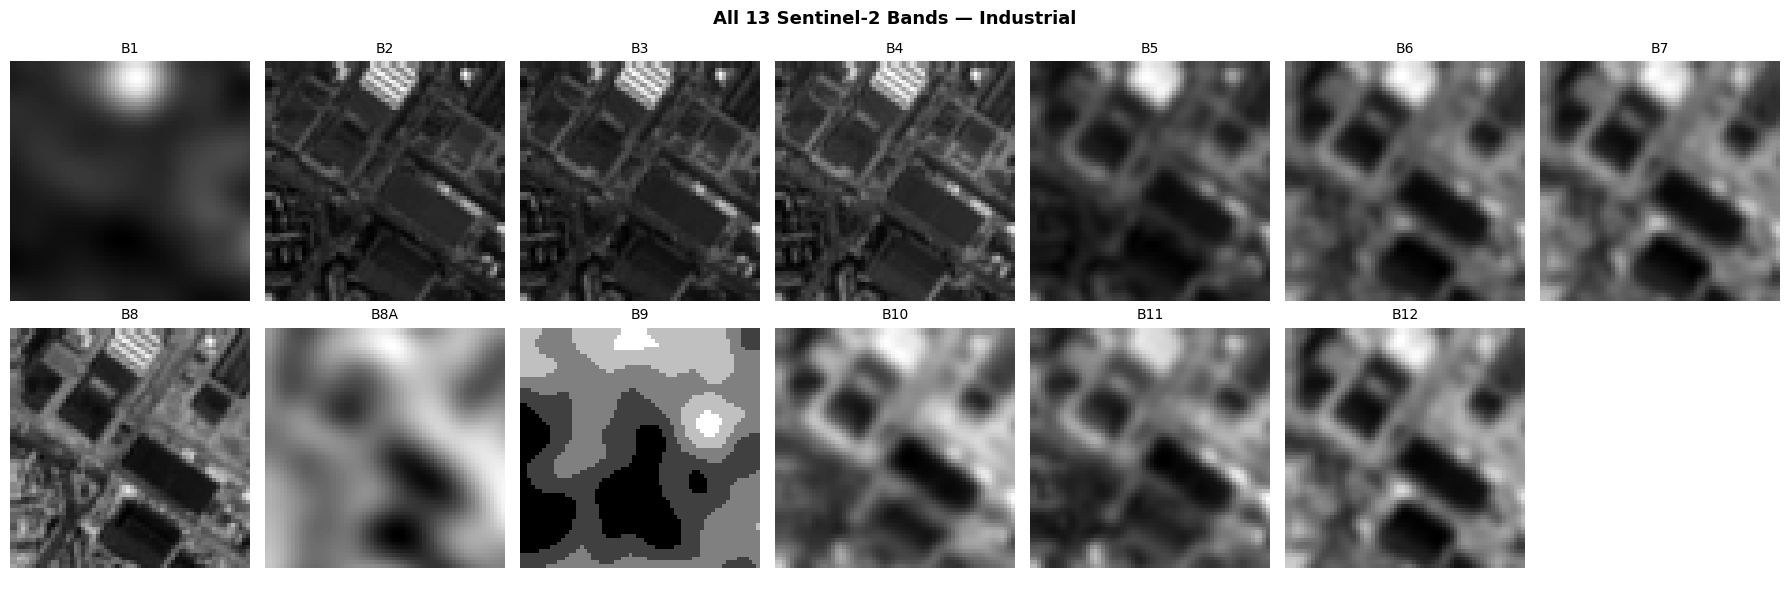

In [8]:
# Visualise all 13 bands for one patch
BAND_NAMES = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B10','B11','B12']

fig, axes = plt.subplots(2, 7, figsize=(18, 6))
axes = axes.flatten()

with rasterio.open(sample_tif) as src:
    for i in range(13):
        band = src.read(i + 1).astype(np.float32)
        band_norm = (band - band.min()) / (band.max() - band.min() + 1e-6)
        axes[i].imshow(band_norm, cmap='gray')
        axes[i].set_title(BAND_NAMES[i], fontsize=10)
        axes[i].axis('off')

# Hide the last unused axis
axes[13].axis('off')

fig.suptitle(f'All 13 Sentinel-2 Bands — {sample_tif.parent.name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('band_overview.png', dpi=120, bbox_inches='tight')
plt.show()

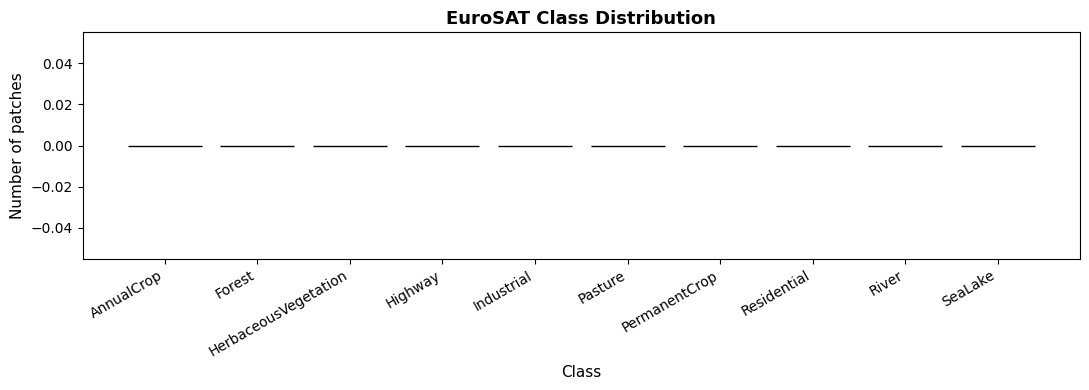

Total patches: 0


In [9]:
# Class distribution
class_counts = {}
for cls in CLASSES:
    cls_dir = Path(CFG['data_root']) / cls
    class_counts[cls] = len(list(cls_dir.glob('*.tif')))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Number of patches', fontsize=11)
ax.set_title('EuroSAT Class Distribution', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Total patches:', sum(class_counts.values()))

In [10]:
# See the actual folder structure inside ds/
from pathlib import Path

ds = Path('./ds')
print("Contents of ds/:")
for p in sorted(ds.iterdir()):
    print(f"  {p.name}/  →  {len(list(p.rglob('*.tif')))} tifs")

Contents of ds/:
  images/  →  27000 tifs


## 4. Preprocessing: Cloud Masking, Normalization & Dataset

In [11]:
def load_tif(path: str, band_indices: list) -> np.ndarray:
    """
    Load specified bands from a GeoTIFF using rasterio.
    Returns float32 array of shape (C, H, W).
    """
    with rasterio.open(path) as src:
        # rasterio bands are 1-indexed
        data = src.read([b + 1 for b in band_indices]).astype(np.float32)
    return data


def cloud_mask(arr_13band: np.ndarray, cirrus_band_idx: int = 10,
               threshold: float = 0.004) -> np.ndarray:
    """
    Simple cirrus cloud mask using Band 10 (B10).
    Pixels where B10 reflectance > threshold are flagged.
    Returns a boolean mask of shape (H, W) — True = cloudy.

    Note: EuroSAT tiles are pre-selected to be largely cloud-free;
    this mask is included to demonstrate the standard Sentinel-2 workflow.
    """
    # Scale raw DN to TOA reflectance (÷ 10000 for Sentinel-2 L1C)
    cirrus = arr_13band[cirrus_band_idx] / 10000.0
    mask = cirrus > threshold
    return mask


def compute_band_stats(file_paths: list, band_indices: list,
                       sample_n: int = 500) -> tuple:
    """
    Compute per-band mean and std from a random sample of files.
    Used for per-channel normalization.
    """
    sample = random.sample(file_paths, min(sample_n, len(file_paths)))
    C = len(band_indices)
    means = np.zeros(C, dtype=np.float64)
    stds  = np.zeros(C, dtype=np.float64)

    for path in tqdm(sample, desc='Computing band stats'):
        arr = load_tif(path, band_indices)    # (C, H, W)
        arr = arr / 10000.0                   # DN → reflectance
        means += arr.mean(axis=(1, 2))
        stds  += arr.std(axis=(1, 2))

    means /= len(sample)
    stds  /= len(sample)
    return means.tolist(), stds.tolist()


# Auto-find the folder that actually contains the class subfolders
def find_class_root(base: Path, classes: list) -> Path:
    """Walk subdirs until we find one that contains known class folders."""
    for root, dirs, _ in os.walk(base):
        root = Path(root)
        if any((root / cls).exists() for cls in classes):
            return root
    raise FileNotFoundError(f"Could not find class folders under {base}")

class_root = find_class_root(Path(CFG['data_root']), CLASSES)
print(f"Class folders found at: {class_root}")

# Collect all file paths and labels
all_paths, all_labels = [], []
for cls in CLASSES:
    cls_dir = class_root / cls
    tifs = list(cls_dir.glob('*.tif'))
    all_paths.extend([str(t) for t in tifs])
    all_labels.extend([CLASS2IDX[cls]] * len(tifs))
    print(f"  {cls}: {len(tifs)} files")

print(f'\nTotal samples: {len(all_paths)}')

Class folders found at: ds/images/remote_sensing/otherDatasets/sentinel_2/tif
  AnnualCrop: 3000 files
  Forest: 3000 files
  HerbaceousVegetation: 3000 files
  Highway: 2500 files
  Industrial: 2500 files
  Pasture: 2000 files
  PermanentCrop: 2500 files
  Residential: 3000 files
  River: 2500 files
  SeaLake: 3000 files

Total samples: 27000


In [12]:
# Pre-compute normalization statistics for both band configs
print('Computing stats for ALL 13 bands ...')
MEAN_ALL, STD_ALL = compute_band_stats(all_paths, CFG['all_bands'], sample_n=600)

# RGB uses the same file — just slice the precomputed means
MEAN_RGB = [MEAN_ALL[i] for i in CFG['rgb_bands']]
STD_RGB  = [STD_ALL[i]  for i in CFG['rgb_bands']]

print(f'All-band  mean: {[round(m,4) for m in MEAN_ALL]}')
print(f'All-band  std : {[round(s,4) for s in STD_ALL]}')
print(f'RGB-only  mean: {[round(m,4) for m in MEAN_RGB]}')
print(f'RGB-only  std : {[round(s,4) for s in STD_RGB]}')

Computing stats for ALL 13 bands ...


Computing band stats: 100%|██████████| 600/600 [00:01<00:00, 386.65it/s]

All-band  mean: [0.1356, 0.1121, 0.1047, 0.0967, 0.1214, 0.198, 0.2336, 0.2268, 0.0734, 0.0012, 0.1843, 0.1145, 0.2563]
All-band  std : [0.0066, 0.0156, 0.0191, 0.0281, 0.0233, 0.0361, 0.0459, 0.0535, 0.0101, 0.0001, 0.0379, 0.0303, 0.0506]
RGB-only  mean: [0.0967, 0.1047, 0.1121]
RGB-only  std : [0.0281, 0.0191, 0.0156]


In [13]:
class EuroSATDataset(Dataset):
    """
    PyTorch Dataset for EuroSAT multispectral GeoTIFFs.

    Parameters
    ----------
    paths       : list of .tif file paths
    labels      : corresponding integer class labels
    band_indices: which Sentinel-2 bands to load
    mean, std   : per-band normalization statistics
    augment     : apply random flips/rotations (training only)
    """

    def __init__(self, paths, labels, band_indices, mean, std, augment=False):
        self.paths        = paths
        self.labels       = labels
        self.band_indices = band_indices
        self.mean         = np.array(mean, dtype=np.float32).reshape(-1, 1, 1)
        self.std          = np.array(std,  dtype=np.float32).reshape(-1, 1, 1)
        self.augment      = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path  = self.paths[idx]
        label = self.labels[idx]

        # Load all 13 bands for cloud masking, then select requested bands
        arr_full = load_tif(path, CFG['all_bands'])             # (13, 64, 64)
        cmask    = cloud_mask(arr_full,
                              CFG['cirrus_band'],
                              CFG['cirrus_thresh'])             # (64, 64) bool

        # Select desired bands
        arr = arr_full[self.band_indices] / 10000.0             # → reflectance

        # Apply cloud mask: set cloudy pixels to 0 across all bands
        arr[:, cmask] = 0.0

        # Per-band normalization
        arr = (arr - self.mean) / (self.std + 1e-6)

        # Data augmentation (training)
        if self.augment:
            if random.random() > 0.5:
                arr = arr[:, :, ::-1].copy()   # horizontal flip
            if random.random() > 0.5:
                arr = arr[:, ::-1, :].copy()   # vertical flip
            k = random.randint(0, 3)
            arr = np.rot90(arr, k, axes=(1, 2)).copy()  # random 90° rotation

        return torch.tensor(arr, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


def make_splits(paths, labels, val_split=0.15, test_split=0.10):
    """Stratified-ish split by shuffling and slicing."""
    idxs = list(range(len(paths)))
    random.shuffle(idxs)
    n = len(idxs)
    n_test = int(n * test_split)
    n_val  = int(n * val_split)

    test_idx  = idxs[:n_test]
    val_idx   = idxs[n_test:n_test + n_val]
    train_idx = idxs[n_test + n_val:]

    def subset(i_list):
        return [paths[i] for i in i_list], [labels[i] for i in i_list]

    return subset(train_idx), subset(val_idx), subset(test_idx)


(tr_paths, tr_labels), (va_paths, va_labels), (te_paths, te_labels) = \
    make_splits(all_paths, all_labels, CFG['val_split'], CFG['test_split'])

print(f'Train: {len(tr_paths)} | Val: {len(va_paths)} | Test: {len(te_paths)}')

Train: 20250 | Val: 4050 | Test: 2700


## 5. Model: Lightweight CNN Classifier

In [14]:
class ConvBlock(nn.Module):
    """Conv → BN → ReLU"""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class LandCoverCNN(nn.Module):
    """
    Lightweight CNN for Sentinel-2 land cover classification.
    Designed to be fast and interpretable — not to maximize performance
    (for that, use a pretrained ViT or ResNet-50 backbone).

    Architecture
    ------------
    Input : (B, C, 64, 64)  — C = 3 (RGB) or 13 (all bands)
    Block1: 64  feature maps, pool → (B, 64,  32, 32)
    Block2: 128 feature maps, pool → (B, 128, 16, 16)
    Block3: 256 feature maps, pool → (B, 256,  8,  8)
    Block4: 256 feature maps, pool → (B, 256,  4,  4)
    GAP   : (B, 256)
    Head  : FC → Dropout → FC → 10 classes
    """

    def __init__(self, in_channels: int, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, 64),
            ConvBlock(64, 64),
            nn.MaxPool2d(2),                    # 64 → 32

            ConvBlock(64, 128),
            ConvBlock(128, 128),
            nn.MaxPool2d(2),                    # 32 → 16

            ConvBlock(128, 256),
            ConvBlock(256, 256),
            nn.MaxPool2d(2),                    # 16 → 8

            ConvBlock(256, 256),
            nn.MaxPool2d(2),                    # 8 → 4
        )
        self.pool = nn.AdaptiveAvgPool2d(1)     # Global Average Pooling
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


# Quick shape check
_m = LandCoverCNN(in_channels=13)
_x = torch.randn(2, 13, 64, 64)
print('Output shape (all-band):', _m(_x).shape)

_m3 = LandCoverCNN(in_channels=3)
_x3 = torch.randn(2, 3, 64, 64)
print('Output shape (RGB)     :', _m3(_x3).shape)

total_params = sum(p.numel() for p in _m.parameters())
print(f'Total parameters (all-band model): {total_params:,}')

Output shape (all-band): torch.Size([2, 10])
Output shape (RGB)     : torch.Size([2, 10])
Total parameters (all-band model): 1,810,762


## 6. Training Loop

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits  = model(images)
        loss    = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


def run_experiment(band_mode: str):
    """
    Full train / val / test loop for a given band configuration.
    band_mode : 'all' | 'rgb'
    """
    assert band_mode in ('all', 'rgb')
    band_indices = CFG['all_bands']  if band_mode == 'all' else CFG['rgb_bands']
    mean         = MEAN_ALL          if band_mode == 'all' else MEAN_RGB
    std          = STD_ALL           if band_mode == 'all' else STD_RGB
    in_channels  = len(band_indices)
    run_name     = f'eurosat_{band_mode}_bands'

    print(f'\n{'='*60}')
    print(f'  Experiment: {run_name}  ({in_channels} input channels)')
    print(f'{'='*60}')

    # ── Datasets & Loaders ───────────────────────────────────────
    train_ds = EuroSATDataset(tr_paths, tr_labels, band_indices, mean, std, augment=True)
    val_ds   = EuroSATDataset(va_paths, va_labels, band_indices, mean, std, augment=False)
    test_ds  = EuroSATDataset(te_paths, te_labels, band_indices, mean, std, augment=False)

    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                              shuffle=True,  num_workers=CFG['num_workers'], pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                              shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                              shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)

    # ── Model, Loss, Optimizer ───────────────────────────────────
    model     = LandCoverCNN(in_channels=in_channels, num_classes=CFG['num_classes']).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])

    # ── MLflow Run ───────────────────────────────────────────────────
    mlflow.set_experiment("eurosat_land_cover")
    active_run = mlflow.start_run(run_name=run_name)
    # Log all hyperparameters
    mlflow.log_params({k: str(v) for k, v in CFG.items()})
    mlflow.log_params({'band_mode': band_mode, 'in_channels': in_channels})

    best_val_acc = 0.0
    best_ckpt    = f'best_{run_name}.pt'

    for epoch in range(1, CFG['epochs'] + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        lr_now = scheduler.get_last_lr()[0]
        print(f'  Ep {epoch:02d}/{CFG["epochs"]} | '
              f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f} | '
              f'va_loss={va_loss:.4f}  va_acc={va_acc:.4f} | '
              f'lr={lr_now:.2e}')

        mlflow.log_metrics({
            'tr_loss': tr_loss, 'tr_acc': tr_acc,
            'va_loss': va_loss, 'va_acc': va_acc,
            'lr'     : lr_now,
        }, step=epoch)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save(model.state_dict(), best_ckpt)

    # ── Test evaluation ──────────────────────────────────────────
    model.load_state_dict(torch.load(best_ckpt))
    te_loss, te_acc, te_preds, te_labels_list = evaluate(model, test_loader, criterion, DEVICE)
    print(f'\n  TEST  acc={te_acc:.4f}  loss={te_loss:.4f}')

    mlflow.log_metrics({'test_acc': te_acc, 'test_loss': te_loss})
    # Log the best checkpoint as an MLflow artifact
    mlflow.log_artifact(best_ckpt, artifact_path='checkpoints')
    mlflow.end_run()

    return model, te_preds, te_labels_list, te_acc

## 7. Ablation Study: RGB-only vs. All-13-Band Input
We train two models with identical architecture and hyperparameters,
differing only in the number of input channels.

In [16]:
# ── MLflow Setup ─────────────────────────────────────────────────────────────
import mlflow

# Set tracking URI to a local folder — no login needed on Colab
MLFLOW_TRACKING_URI = "./mlruns"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("eurosat_land_cover")

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print("Experiment          : eurosat_land_cover")
print("Run  `mlflow ui`  in your terminal (or use the Colab MLflow extension) to inspect runs.")


2026/05/04 10:44:59 INFO mlflow.tracking.fluent: Experiment with name 'eurosat_land_cover' does not exist. Creating a new experiment.


MLflow tracking URI : ./mlruns
Experiment          : eurosat_land_cover
Run  `mlflow ui`  in your terminal (or use the Colab MLflow extension) to inspect runs.


In [17]:
# ── Run 1: All 13 bands ───────────────────────────────────────────────────────
model_all, preds_all, labels_all, acc_all = run_experiment('all')


  Experiment: eurosat_all_bands  (13 input channels)
  Ep 01/30 | tr_loss=2.1994  tr_acc=0.1673 | va_loss=4.3066  va_acc=0.1091 | lr=9.97e-04
  Ep 02/30 | tr_loss=2.1911  tr_acc=0.1708 | va_loss=2.2107  va_acc=0.1637 | lr=9.89e-04
  Ep 03/30 | tr_loss=2.1889  tr_acc=0.1721 | va_loss=2.1900  va_acc=0.1642 | lr=9.76e-04
  Ep 04/30 | tr_loss=2.1885  tr_acc=0.1683 | va_loss=2.1875  va_acc=0.1714 | lr=9.57e-04
  Ep 05/30 | tr_loss=2.1861  tr_acc=0.1695 | va_loss=4.2841  va_acc=0.1091 | lr=9.33e-04
  Ep 06/30 | tr_loss=2.1858  tr_acc=0.1655 | va_loss=2.1896  va_acc=0.1714 | lr=9.05e-04
  Ep 07/30 | tr_loss=2.1851  tr_acc=0.1720 | va_loss=4.3147  va_acc=0.1091 | lr=8.72e-04
  Ep 08/30 | tr_loss=2.1849  tr_acc=0.1741 | va_loss=3.6182  va_acc=0.1091 | lr=8.35e-04
  Ep 09/30 | tr_loss=2.1849  tr_acc=0.1689 | va_loss=2.1862  va_acc=0.1679 | lr=7.94e-04
  Ep 10/30 | tr_loss=2.1850  tr_acc=0.1694 | va_loss=2.1869  va_acc=0.1642 | lr=7.50e-04
  Ep 11/30 | tr_loss=2.1842  tr_acc=0.1719 | va_loss=2.3

In [18]:
# ── Run 2: RGB only ───────────────────────────────────────────────────────────
model_rgb, preds_rgb, labels_rgb, acc_rgb = run_experiment('rgb')


  Experiment: eurosat_rgb_bands  (3 input channels)
  Ep 01/30 | tr_loss=2.1995  tr_acc=0.1697 | va_loss=2.1938  va_acc=0.1672 | lr=9.97e-04
  Ep 02/30 | tr_loss=2.1914  tr_acc=0.1708 | va_loss=2.2714  va_acc=0.1091 | lr=9.89e-04
  Ep 03/30 | tr_loss=2.1902  tr_acc=0.1687 | va_loss=2.1882  va_acc=0.1679 | lr=9.76e-04
  Ep 04/30 | tr_loss=2.1881  tr_acc=0.1690 | va_loss=2.1872  va_acc=0.1711 | lr=9.57e-04
  Ep 05/30 | tr_loss=2.1875  tr_acc=0.1689 | va_loss=2.6640  va_acc=0.1091 | lr=9.33e-04
  Ep 06/30 | tr_loss=2.1866  tr_acc=0.1698 | va_loss=2.1866  va_acc=0.1679 | lr=9.05e-04
  Ep 07/30 | tr_loss=2.1861  tr_acc=0.1707 | va_loss=2.1871  va_acc=0.1642 | lr=8.72e-04
  Ep 08/30 | tr_loss=2.1856  tr_acc=0.1670 | va_loss=2.1873  va_acc=0.1679 | lr=8.35e-04
  Ep 09/30 | tr_loss=2.1851  tr_acc=0.1662 | va_loss=3.8375  va_acc=0.1091 | lr=7.94e-04
  Ep 10/30 | tr_loss=2.1858  tr_acc=0.1682 | va_loss=2.1865  va_acc=0.1714 | lr=7.50e-04
  Ep 11/30 | tr_loss=2.1849  tr_acc=0.1709 | va_loss=2.18

In [19]:
# Summary comparison
print('\n' + '='*45)
print(f'  ABLATION RESULTS (Test Accuracy)')
print('='*45)
print(f'  All 13 bands : {acc_all*100:.2f}%')
print(f'  RGB only     : {acc_rgb*100:.2f}%')
print(f'  Delta        : {(acc_all - acc_rgb)*100:+.2f}%')
print('='*45)


  ABLATION RESULTS (Test Accuracy)
  All 13 bands : 17.41%
  RGB only     : 17.48%
  Delta        : -0.07%


## 8. Evaluation: Confusion Matrix & Classification Report

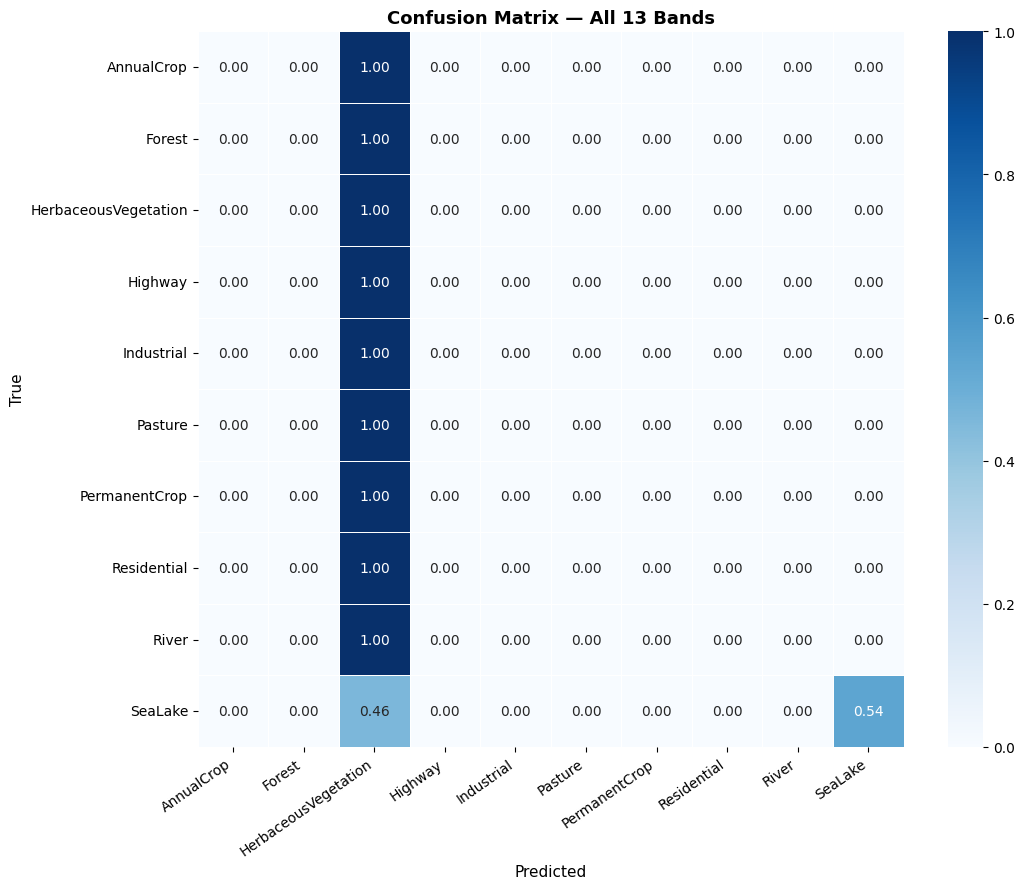

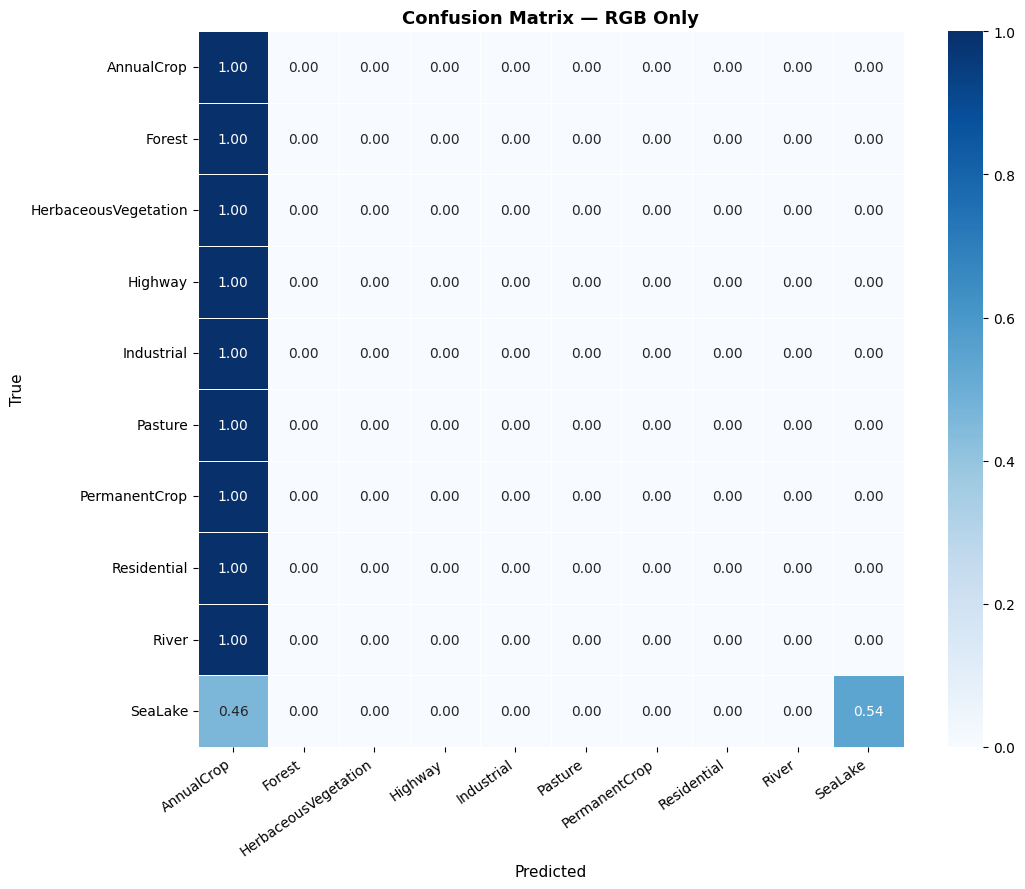

In [20]:
def plot_confusion_matrix(preds, labels, title, filename):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.4, ax=ax)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True',      fontsize=11)
    ax.set_title(title,        fontsize=13, fontweight='bold')
    plt.xticks(rotation=35, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=130, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(preds_all, labels_all,
                      title='Confusion Matrix — All 13 Bands',
                      filename='cm_all_bands.png')

plot_confusion_matrix(preds_rgb, labels_rgb,
                      title='Confusion Matrix — RGB Only',
                      filename='cm_rgb.png')

In [21]:
print('Classification Report — All 13 Bands')
print(classification_report(labels_all, preds_all, target_names=CLASSES))

print('\nClassification Report — RGB Only')
print(classification_report(labels_rgb, preds_rgb, target_names=CLASSES))

Classification Report — All 13 Bands
                      precision    recall  f1-score   support

          AnnualCrop       0.00      0.00      0.00       300
              Forest       0.00      0.00      0.00       280
HerbaceousVegetation       0.12      1.00      0.21       298
             Highway       0.00      0.00      0.00       239
          Industrial       0.00      0.00      0.00       241
             Pasture       0.00      0.00      0.00       203
       PermanentCrop       0.00      0.00      0.00       257
         Residential       0.00      0.00      0.00       307
               River       0.00      0.00      0.00       257
             SeaLake       1.00      0.54      0.70       318

            accuracy                           0.17      2700
           macro avg       0.11      0.15      0.09      2700
        weighted avg       0.13      0.17      0.11      2700


Classification Report — RGB Only
                      precision    recall  f1-score   supp

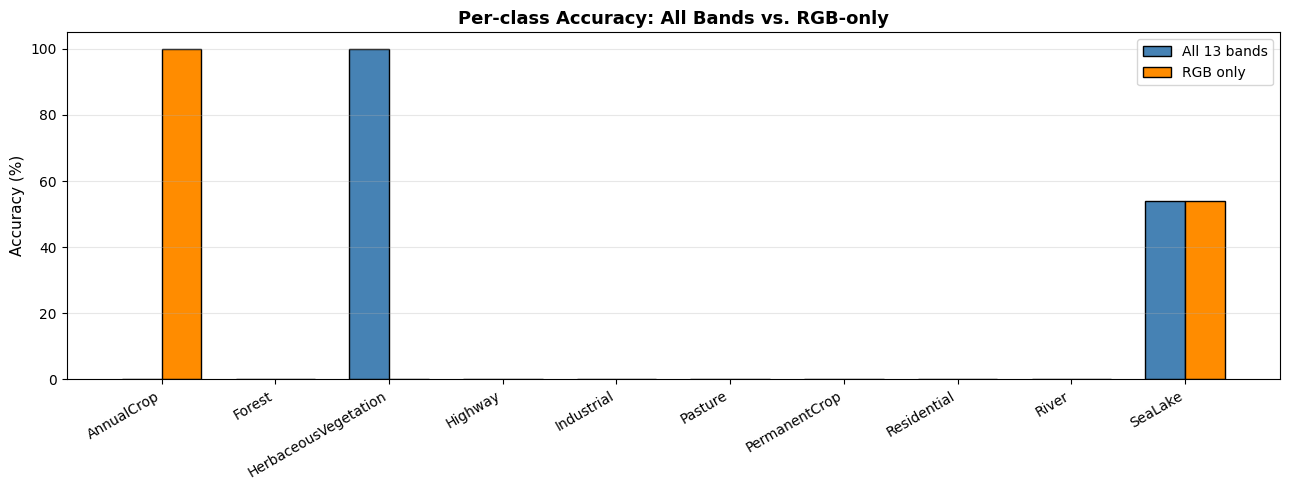

In [22]:
# Per-class accuracy comparison bar chart
cm_all = confusion_matrix(labels_all, preds_all)
cm_rgb = confusion_matrix(labels_rgb, preds_rgb)
acc_per_class_all = cm_all.diagonal() / cm_all.sum(axis=1)
acc_per_class_rgb = cm_rgb.diagonal() / cm_rgb.sum(axis=1)

x = np.arange(len(CLASSES))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, acc_per_class_all * 100, width=w, label='All 13 bands', color='steelblue',  edgecolor='black')
ax.bar(x + w/2, acc_per_class_rgb * 100, width=w, label='RGB only',     color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-class Accuracy: All Bands vs. RGB-only', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()

## 9. Visual Predictions on Test Samples

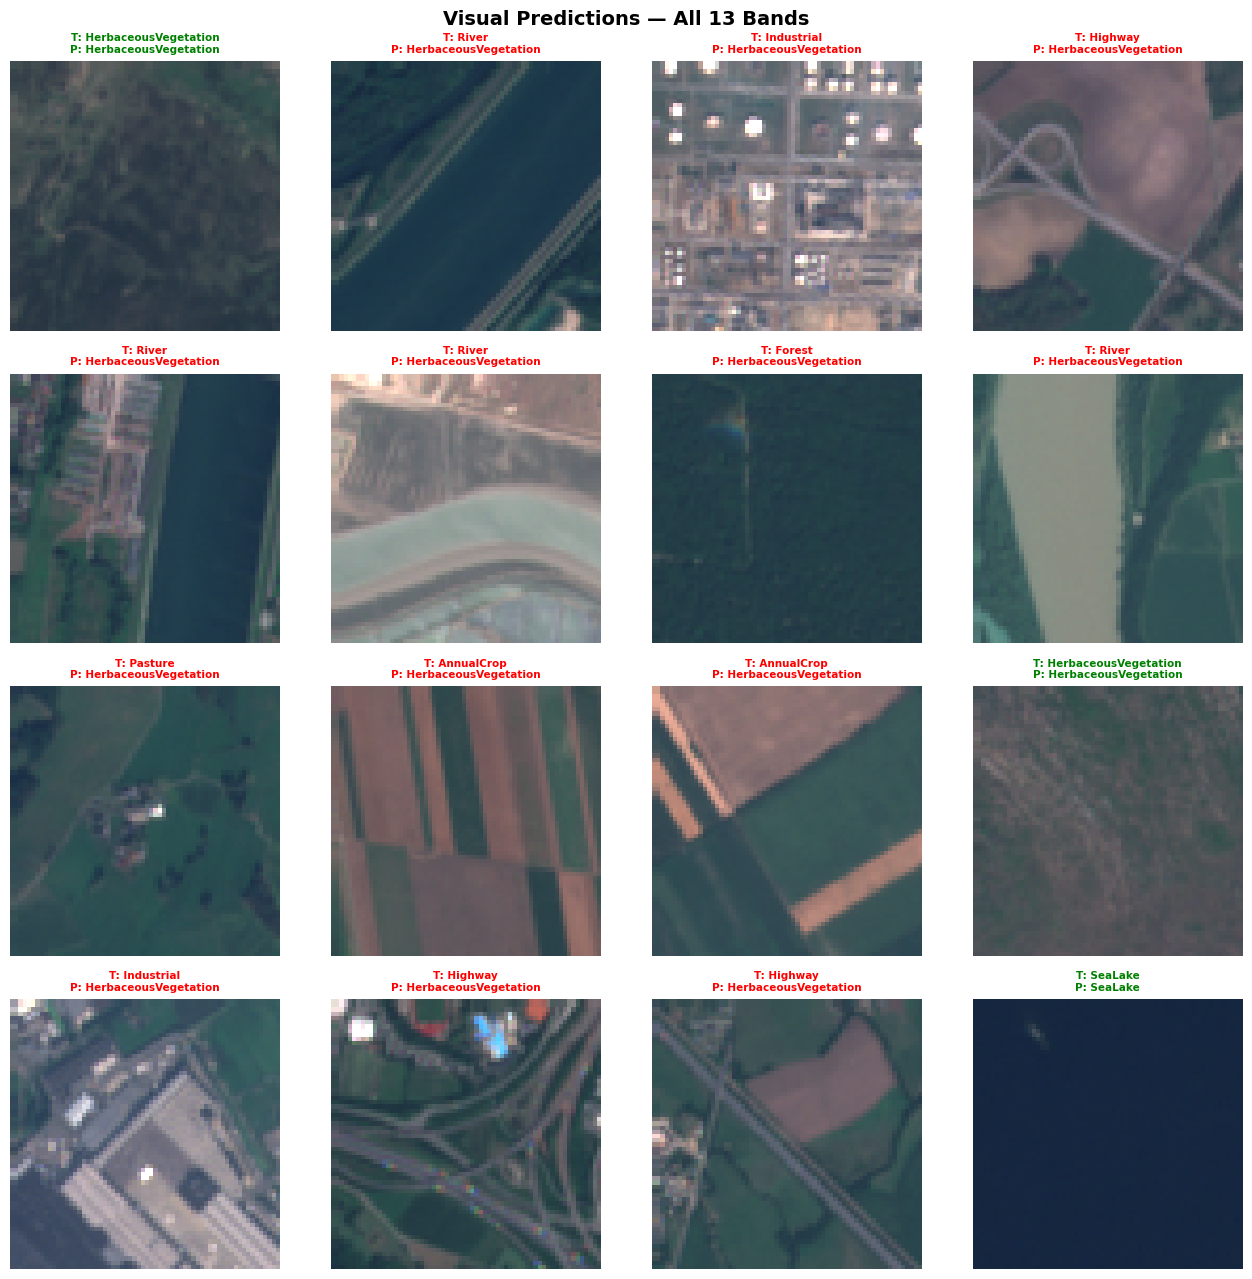

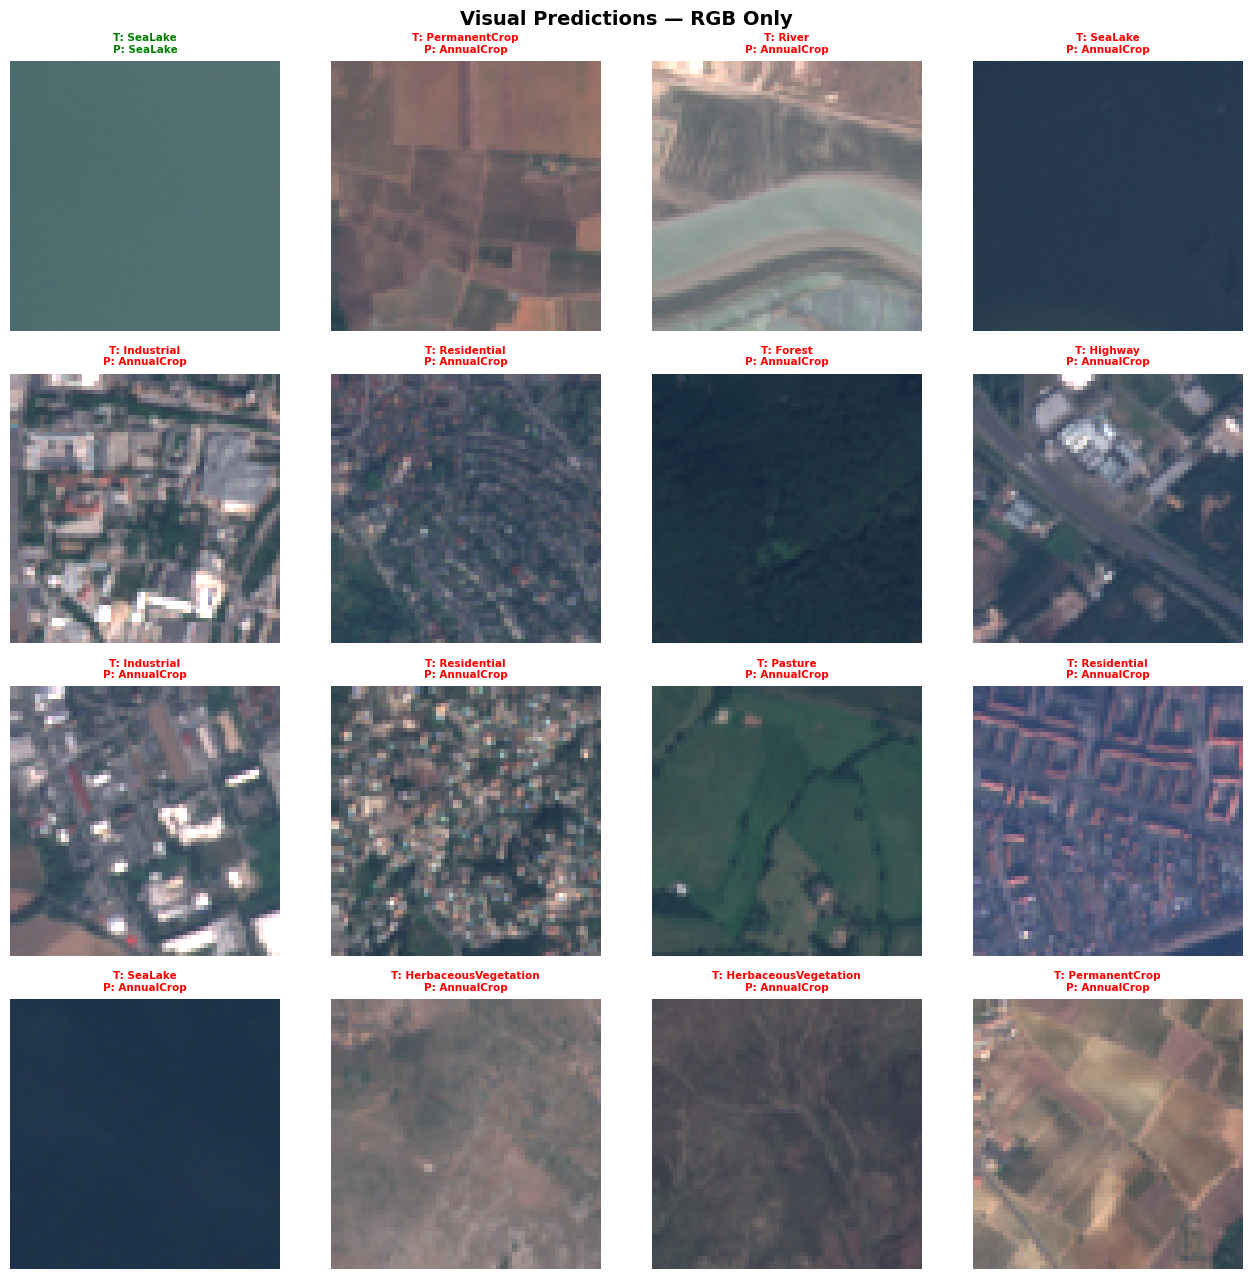

In [23]:
@torch.no_grad()
def visualise_predictions(model, paths, labels, band_indices, mean, std,
                           n_samples=16, title='Predictions'):
    """
    Show a grid of test patches with true and predicted labels.
    Renders as an RGB composite (B4-B3-B2) regardless of model band mode.
    """
    model.eval()
    idxs = random.sample(range(len(paths)), n_samples)

    fig, axes = plt.subplots(4, 4, figsize=(13, 13))
    axes = axes.flatten()

    for ax_i, idx in enumerate(idxs):
        path  = paths[idx]
        label = labels[idx]

        # Load for model input
        arr_full = load_tif(path, CFG['all_bands'])
        cmask    = cloud_mask(arr_full, CFG['cirrus_band'], CFG['cirrus_thresh'])
        arr      = arr_full[band_indices] / 10000.0
        arr[:, cmask] = 0.0

        mean_np = np.array(mean, dtype=np.float32).reshape(-1, 1, 1)
        std_np  = np.array(std,  dtype=np.float32).reshape(-1, 1, 1)
        arr_norm = (arr - mean_np) / (std_np + 1e-6)

        tensor = torch.tensor(arr_norm[None], dtype=torch.float32).to(DEVICE)
        logits = model(tensor)
        pred   = logits.argmax(dim=1).item()

        # Render RGB for display (B4=red, B3=green, B2=blue, indices 3,2,1)
        rgb = arr_full[[3, 2, 1]] / 10000.0      # (3, 64, 64)
        rgb = np.clip(rgb * 3.5, 0, 1)           # brighten
        rgb = np.transpose(rgb, (1, 2, 0))        # (64, 64, 3)

        axes[ax_i].imshow(rgb)
        correct = (pred == label)
        color   = 'green' if correct else 'red'
        axes[ax_i].set_title(
            f'T: {CLASSES[label]}\nP: {CLASSES[pred]}',
            fontsize=7.5, color=color, fontweight='bold'
        )
        axes[ax_i].axis('off')

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=130, bbox_inches='tight')
    plt.show()


visualise_predictions(
    model_all, te_paths, te_labels, CFG['all_bands'], MEAN_ALL, STD_ALL,
    title='Visual Predictions — All 13 Bands'
)

visualise_predictions(
    model_rgb, te_paths, te_labels, CFG['rgb_bands'], MEAN_RGB, STD_RGB,
    title='Visual Predictions — RGB Only'
)

## 10. Save Final Models & Artefacts

In [24]:
torch.save(model_all.state_dict(), 'eurosat_cnn_all_bands_final.pt')
torch.save(model_rgb.state_dict(), 'eurosat_cnn_rgb_final.pt')

# Save summary stats to a text file
with open('ablation_results.txt', 'w') as f:
    f.write('EuroSAT CNN — Ablation Results\n')
    f.write('='*40 + '\n')
    f.write(f'All 13 bands  test acc: {acc_all*100:.2f}%\n')
    f.write(f'RGB only      test acc: {acc_rgb*100:.2f}%\n')
    f.write(f'Delta                 : {(acc_all - acc_rgb)*100:+.2f}%\n')
    f.write('\nAll-band Classification Report:\n')
    f.write(classification_report(labels_all, preds_all, target_names=CLASSES))
    f.write('\nRGB Classification Report:\n')
    f.write(classification_report(labels_rgb, preds_rgb, target_names=CLASSES))

print('Saved: eurosat_cnn_all_bands_final.pt')
print('Saved: eurosat_cnn_rgb_final.pt')
print('Saved: ablation_results.txt')
print('\nAll done!')

Saved: eurosat_cnn_all_bands_final.pt
Saved: eurosat_cnn_rgb_final.pt
Saved: ablation_results.txt

All done!
